# SARIMA Time Series Model

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pmdarima as pm

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv('../COS40007DataCleaning/combined_air_electricity_ipi_cleaned.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)
df.index.freq = 'MS'  # Monthly Start frequency

# Select relevant columns
target = df['air_so2']
exog = df[['ipi_abs_index_sa', 'electricity_local']]

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.index.min()} → {df.index.max()}')
print(f'\nTarget (SO₂) summary:')
print(target.describe())
print(f'\nExogenous features summary:')
print(exog.describe())

Dataset shape: (60, 18)
Date range: 2018-01-01 00:00:00 → 2022-12-01 00:00:00

Target (SO₂) summary:
count    60.000000
mean      0.001083
std       0.000096
min       0.000900
25%       0.001000
50%       0.001100
75%       0.001125
max       0.001300
Name: air_so2, dtype: float64

Exogenous features summary:
       ipi_abs_index_sa  electricity_local
count         60.000000          60.000000
mean         116.330733       12408.987720
std            7.923553         618.107361
min           79.766000       10349.141635
25%          113.035250       12056.077210
50%          115.157500       12485.375480
75%          120.355250       12823.768369
max          130.293000       13463.730428


## 3. Exploratory Data Analysis

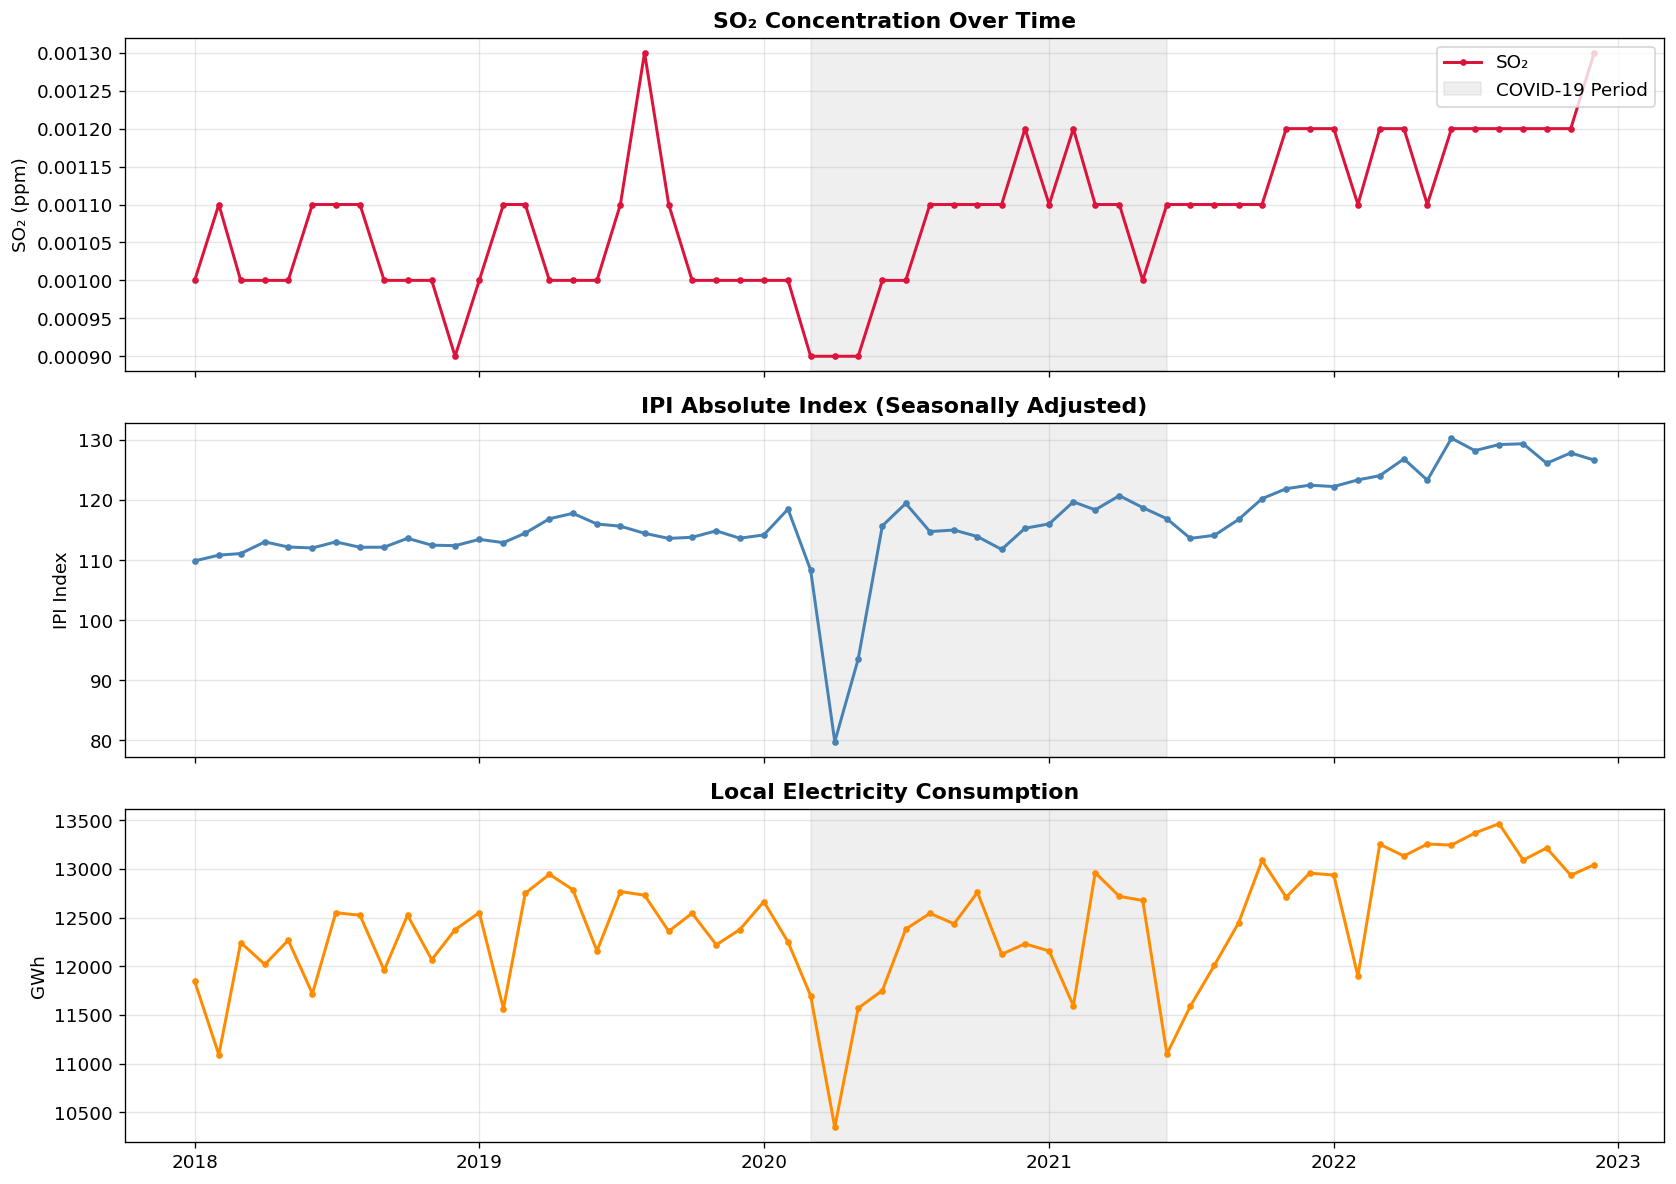

Figure saved: 01_time_series_overview.png


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(target.index, target.values, color='crimson', linewidth=1.8, marker='o', markersize=3)
axes[0].set_title('SO₂ Concentration Over Time', fontweight='bold')
axes[0].set_ylabel('SO₂ (ppm)')
axes[0].grid(alpha=0.3)

axes[1].plot(exog.index, exog['ipi_abs_index_sa'], color='steelblue', linewidth=1.8, marker='o', markersize=3)
axes[1].set_title('IPI Absolute Index (Seasonally Adjusted)', fontweight='bold')
axes[1].set_ylabel('IPI Index')
axes[1].grid(alpha=0.3)

axes[2].plot(exog.index, exog['electricity_local'], color='darkorange', linewidth=1.8, marker='o', markersize=3)
axes[2].set_title('Local Electricity Consumption', fontweight='bold')
axes[2].set_ylabel('GWh')
axes[2].grid(alpha=0.3)

# Shade COVID period
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), 
               alpha=0.12, color='gray', label='COVID-19 Period')

axes[0].legend(['SO₂', 'COVID-19 Period'], loc='upper right')
plt.tight_layout()
plt.savefig('01_time_series_overview.png', bbox_inches='tight')
plt.show()
print('Figure saved: 01_time_series_overview.png')

Pearson Correlation Matrix:
                      SO2  IPI_SA  Electricity_Local
SO2                1.0000  0.6768             0.5012
IPI_SA             0.6768  1.0000             0.7503
Electricity_Local  0.5012  0.7503             1.0000


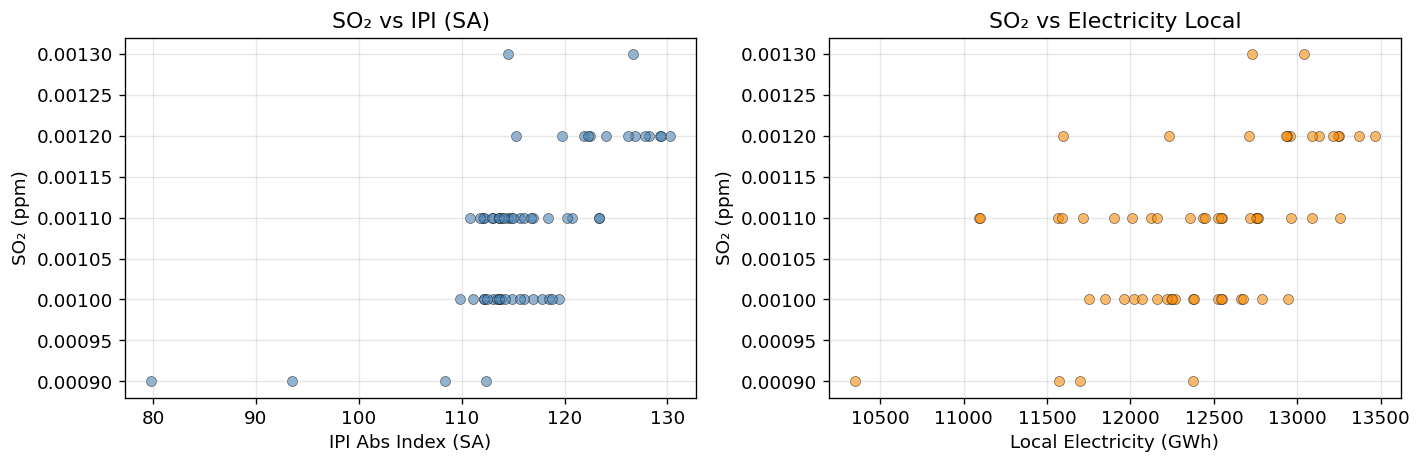

In [4]:
# Correlation analysis
corr_df = pd.DataFrame({
    'SO2': target,
    'IPI_SA': exog['ipi_abs_index_sa'],
    'Electricity_Local': exog['electricity_local']
})

print('Pearson Correlation Matrix:')
print(corr_df.corr().round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(exog['ipi_abs_index_sa'], target, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.4)
axes[0].set_xlabel('IPI Abs Index (SA)')
axes[0].set_ylabel('SO₂ (ppm)')
axes[0].set_title('SO₂ vs IPI (SA)')
axes[0].grid(alpha=0.3)

axes[1].scatter(exog['electricity_local'], target, alpha=0.6, color='darkorange', edgecolors='k', linewidths=0.4)
axes[1].set_xlabel('Local Electricity (GWh)')
axes[1].set_ylabel('SO₂ (ppm)')
axes[1].set_title('SO₂ vs Electricity Local')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_correlation_scatter.png', bbox_inches='tight')
plt.show()

## 4. Stationarity Tests

In [5]:
def stationarity_tests(series, name):
    print(f"{'='*55}")
    print(f"  Stationarity Tests for: {name}")
    print(f"{'='*55}")
    
    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    adf_stat, adf_p = adf_result[0], adf_result[1]
    print(f"  ADF Test Statistic : {adf_stat:.4f}")
    print(f"  ADF p-value        : {adf_p:.4f}")
    print(f"  ADF Decision       : {'STATIONARY' if adf_p < 0.05 else 'NON-STATIONARY'}")
    
    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    print(f"  KPSS Test Statistic: {kpss_stat:.4f}")
    print(f"  KPSS p-value       : {kpss_p:.4f}")
    print(f"  KPSS Decision      : {'STATIONARY' if kpss_p > 0.05 else 'NON-STATIONARY'}")
    print()

stationarity_tests(target, 'SO₂ (original)')
stationarity_tests(target.diff().dropna(), 'SO₂ (1st difference, d=1)')
stationarity_tests(target.diff(12).dropna(), 'SO₂ (seasonal difference, D=1, s=12)')

  Stationarity Tests for: SO₂ (original)
  ADF Test Statistic : 0.5233
  ADF p-value        : 0.9856
  ADF Decision       : NON-STATIONARY
  KPSS Test Statistic: 0.8044
  KPSS p-value       : 0.0100
  KPSS Decision      : NON-STATIONARY

  Stationarity Tests for: SO₂ (1st difference, d=1)
  ADF Test Statistic : -5.5339
  ADF p-value        : 0.0000
  ADF Decision       : STATIONARY
  KPSS Test Statistic: 0.0953
  KPSS p-value       : 0.1000
  KPSS Decision      : STATIONARY

  Stationarity Tests for: SO₂ (seasonal difference, D=1, s=12)
  ADF Test Statistic : -1.8598
  ADF p-value        : 0.3512
  ADF Decision       : NON-STATIONARY
  KPSS Test Statistic: 0.2873
  KPSS p-value       : 0.1000
  KPSS Decision      : STATIONARY



C:\Users\USER\AppData\Local\Temp\ipykernel_38072\3949291266.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\USER\AppData\Local\Temp\ipykernel_38072\3949291266.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\USER\AppData\Local\Temp\ipykernel_38072\3949291266.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')


## 5. ACF & PACF Analysis

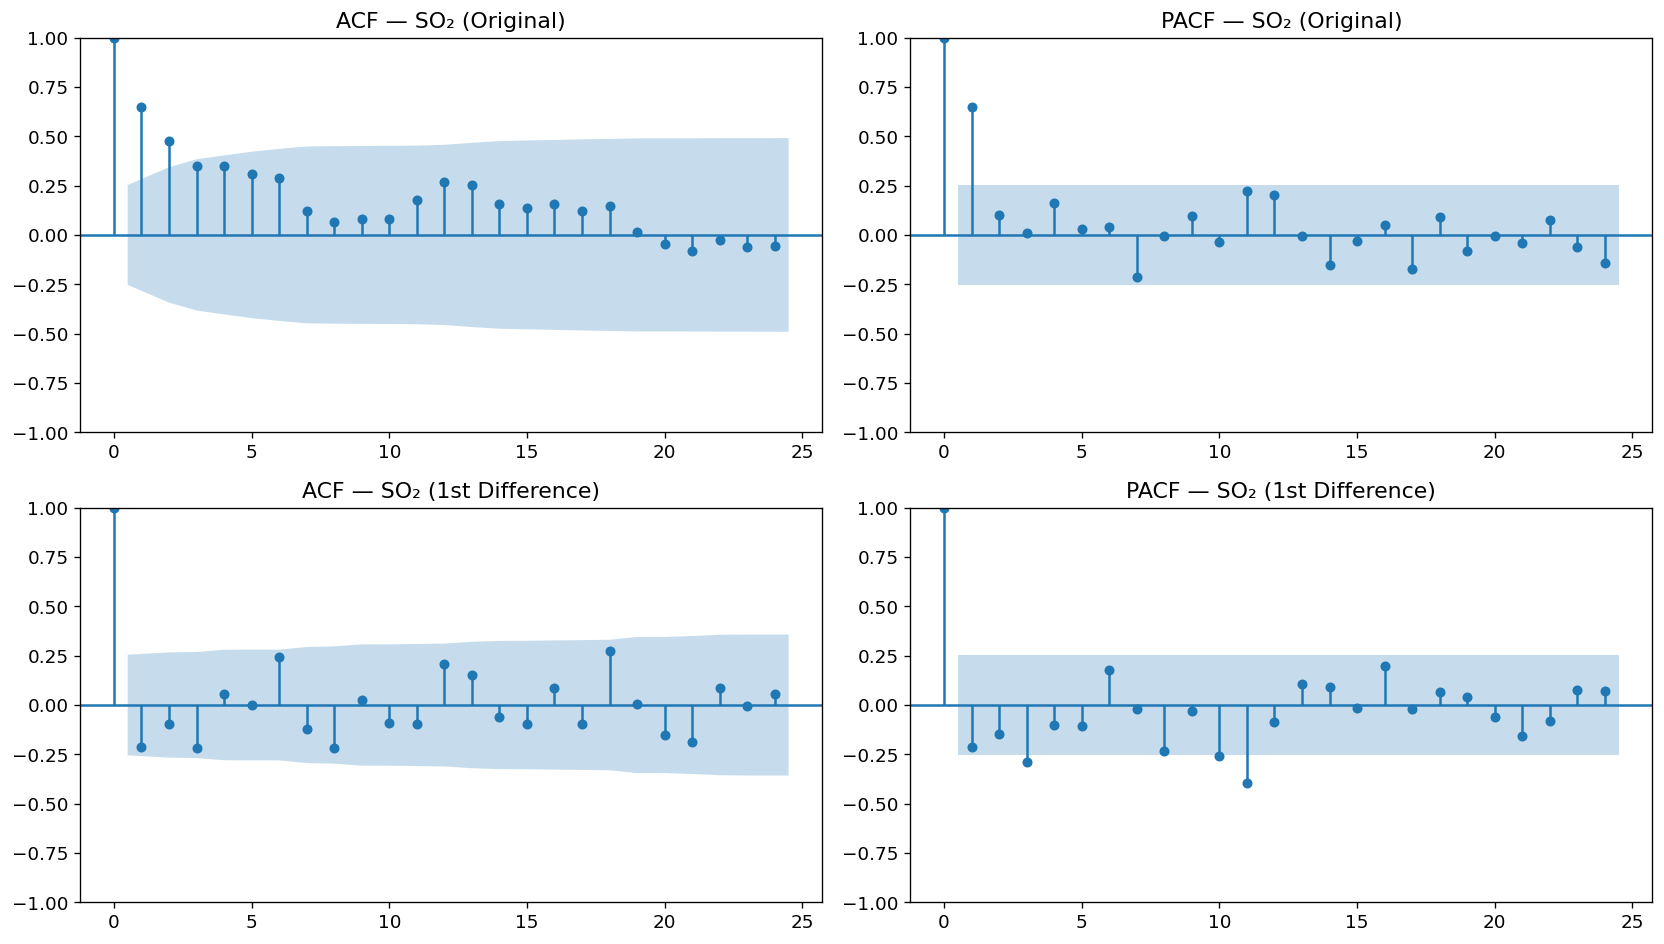

Figure saved: 03_acf_pacf.png

Interpretation Guide:
  - Significant spikes at lag k in PACF → AR order p = k
  - Significant spikes at lag k in ACF  → MA order q = k
  - Significant spikes at seasonal lags (12, 24) → seasonal P or Q


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original series
plot_acf(target, lags=24, ax=axes[0, 0], title='ACF — SO₂ (Original)')
plot_pacf(target, lags=24, ax=axes[0, 1], title='PACF — SO₂ (Original)', method='ywm')

# After differencing
target_diff = target.diff().dropna()
plot_acf(target_diff, lags=24, ax=axes[1, 0], title='ACF — SO₂ (1st Difference)')
plot_pacf(target_diff, lags=24, ax=axes[1, 1], title='PACF — SO₂ (1st Difference)', method='ywm')

plt.tight_layout()
plt.savefig('03_acf_pacf.png', bbox_inches='tight')
plt.show()
print('Figure saved: 03_acf_pacf.png')
print()
print('Interpretation Guide:')
print('  - Significant spikes at lag k in PACF → AR order p = k')
print('  - Significant spikes at lag k in ACF  → MA order q = k')
print('  - Significant spikes at seasonal lags (12, 24) → seasonal P or Q')

## 6. Train / Test Split

Training set : 2018-01-01 → 2021-12-01  (48 months)
Test set     : 2022-01-01  → 2022-12-01   (12 months)


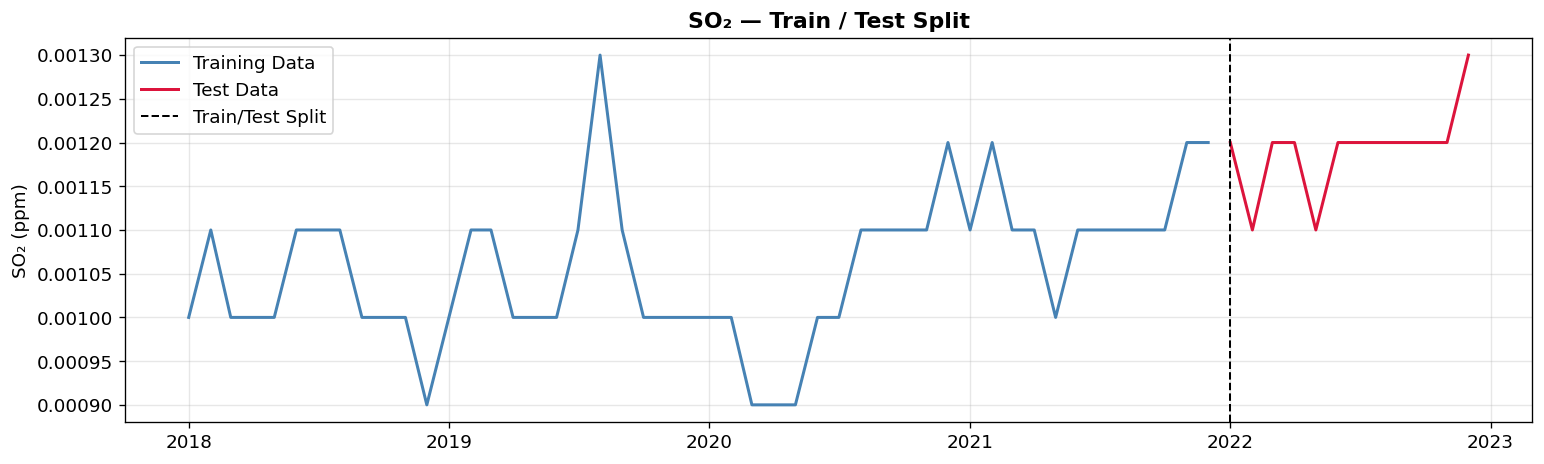

In [7]:
TRAIN_SIZE = 48  # 80%

train_y = target.iloc[:TRAIN_SIZE]
test_y  = target.iloc[TRAIN_SIZE:]

train_exog = exog.iloc[:TRAIN_SIZE]
test_exog  = exog.iloc[TRAIN_SIZE:]

print(f'Training set : {train_y.index[0].date()} → {train_y.index[-1].date()}  ({len(train_y)} months)')
print(f'Test set     : {test_y.index[0].date()}  → {test_y.index[-1].date()}   ({len(test_y)} months)')

# Visualise split
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_y.index, train_y.values, label='Training Data', color='steelblue', linewidth=1.8)
ax.plot(test_y.index,  test_y.values,  label='Test Data',     color='crimson',   linewidth=1.8)
ax.axvline(x=test_y.index[0], color='black', linestyle='--', linewidth=1.2, label='Train/Test Split')
ax.set_title('SO₂ — Train / Test Split', fontweight='bold')
ax.set_ylabel('SO₂ (ppm)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('04_train_test_split.png', bbox_inches='tight')
plt.show()

## 7. Auto-ARIMA - Automatic Order Selection

In [8]:
print('Running auto_arima (stepwise search) — this may take ~1 minute...')
print()

auto_model = pm.auto_arima(
    train_y,
    X=train_exog,           # exogenous: IPI_SA + electricity_local
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,                 # auto-determine d via ADF test
    seasonal=True,
    m=12,                   # 12-month seasonality
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,                 # auto-determine D
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True              # print candidate models
)

order         = auto_model.order
seasonal_order = auto_model.seasonal_order
print()
print(f'Best SARIMA order          : {order}')
print(f'Best seasonal order (s=12) : {seasonal_order}')
print(f'AIC : {auto_model.aic():.4f}')
print(f'BIC : {auto_model.bic():.4f}')

Running auto_arima (stepwise search) — this may take ~1 minute...

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-767.840, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-768.810, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-769.734, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=-631.016, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=-771.734, Time=0.05 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=-769.949, Time=0.12 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=-766.612, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=-769.881, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[12] intercept   : AIC=-769.028, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=-770.699, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=-767.285, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[12]             : AIC=-773.733, Time=0.05 sec
 ARIMA(0,0,1)(1,0,0)[12]             : AIC=-771.948, Time=0.12 sec
 ARIMA(0,0,1)(0,0,1

## 8. Fit SARIMAX Model 

In [9]:
sarima_model = SARIMAX(
    train_y,
    exog=train_exog,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                air_so2   No. Observations:                   48
Model:               SARIMAX(0, 0, 1)   Log Likelihood                 374.788
Date:                Sat, 06 Jun 2026   AIC                           -741.575
Time:                        00:35:16   BIC                           -734.260
Sample:                    01-01-2018   HQIC                          -738.835
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
ipi_abs_index_sa   7.718e-06   1.65e-06      4.691      0.000    4.49e-06    1.09e-05
electricity_local  1.447e-08   1.53e-08      0.944      0.345   -1.56e-08    4.45e-08
ma.L1                 0.

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 9. Forecast on Test Set

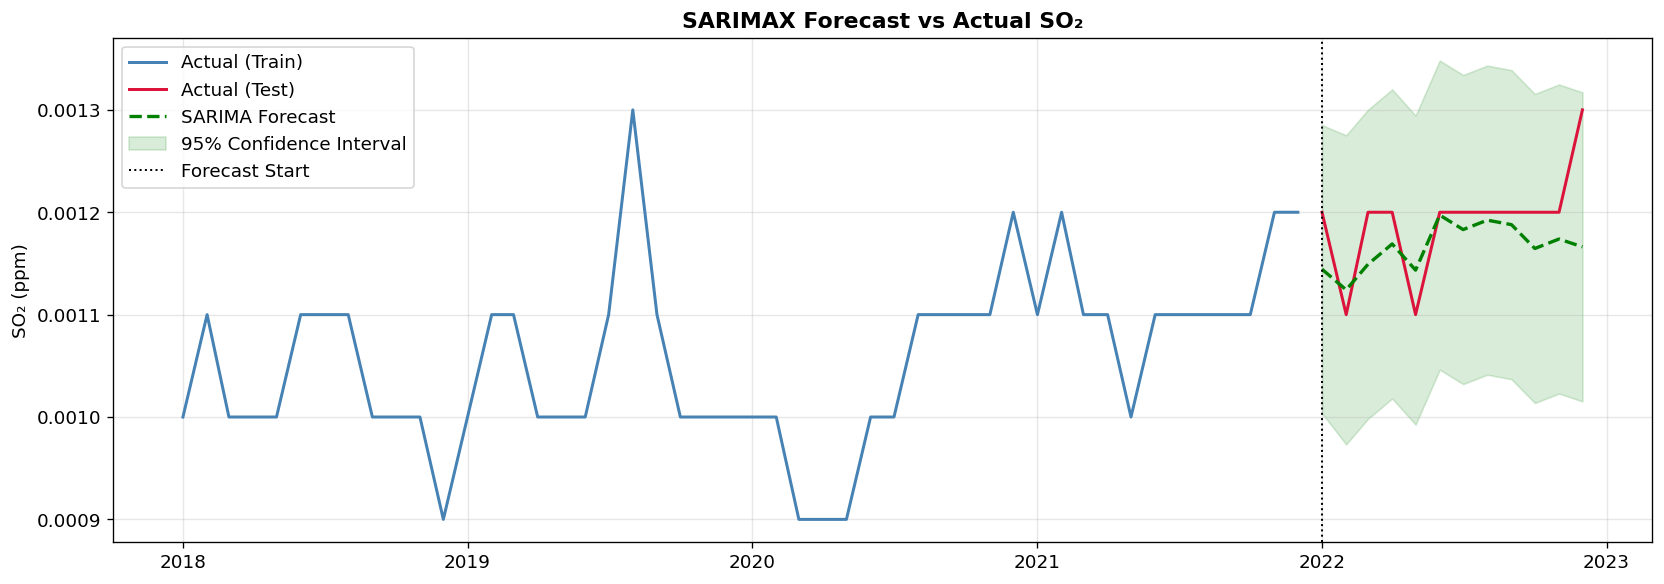

Figure saved: 05_actual_vs_predicted.png


In [10]:
forecast_obj = sarima_fit.get_forecast(steps=len(test_y), exog=test_exog)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)  # 95% confidence interval

# In-sample fitted values
fitted_values = sarima_fit.fittedvalues

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_y.index, train_y.values, label='Actual (Train)', color='steelblue', linewidth=1.8)
ax.plot(test_y.index,  test_y.values,  label='Actual (Test)',  color='crimson',   linewidth=1.8)
ax.plot(test_y.index,  forecast_mean,  label='SARIMA Forecast', color='green', linewidth=2, linestyle='--')
ax.fill_between(
    test_y.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='green', alpha=0.15, label='95% Confidence Interval'
)
ax.axvline(x=test_y.index[0], color='black', linestyle=':', linewidth=1.2, label='Forecast Start')
ax.set_title('SARIMAX Forecast vs Actual SO₂', fontweight='bold')
ax.set_ylabel('SO₂ (ppm)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('05_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print('Figure saved: 05_actual_vs_predicted.png')

## 10. Evaluation Metrics

In [11]:
def evaluate_model(actual, predicted, label='Test'):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2   = r2_score(actual, predicted)
    
    print(f"\n{'='*45}")
    print(f"  SARIMAX Evaluation — {label} Set")
    print(f"{'='*45}")
    print(f"  MAE  (Mean Absolute Error)       : {mae:.6f}")
    print(f"  RMSE (Root Mean Squared Error)   : {rmse:.6f}")
    print(f"  MAPE (Mean Abs Percentage Error) : {mape:.2f}%")
    print(f"  R²   (Coefficient of Determination): {r2:.4f}")
    print(f"{'='*45}")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# Test set evaluation
test_metrics = evaluate_model(test_y.values, forecast_mean.values, label='Test (2022)')

# Training set evaluation (in-sample)
train_metrics = evaluate_model(train_y.values, fitted_values.values, label='Train (2018–2021)')

# Save metrics
metrics_df = pd.DataFrame([train_metrics, test_metrics], index=['Train', 'Test'])
print('\nMetrics Summary:')
print(metrics_df.round(6))


  SARIMAX Evaluation — Test (2022) Set
  MAE  (Mean Absolute Error)       : 0.000037
  RMSE (Root Mean Squared Error)   : 0.000050
  MAPE (Mean Abs Percentage Error) : 3.03%
  R²   (Coefficient of Determination): -0.0099

  SARIMAX Evaluation — Train (2018–2021) Set
  MAE  (Mean Absolute Error)       : 0.000056
  RMSE (Root Mean Squared Error)   : 0.000070
  MAPE (Mean Abs Percentage Error) : 5.30%
  R²   (Coefficient of Determination): 0.3135

Metrics Summary:
            MAE     RMSE      MAPE        R2
Train  0.000056  0.00007  5.299335  0.313457
Test   0.000037  0.00005  3.026899 -0.009911


## 11. Residual Diagnostics

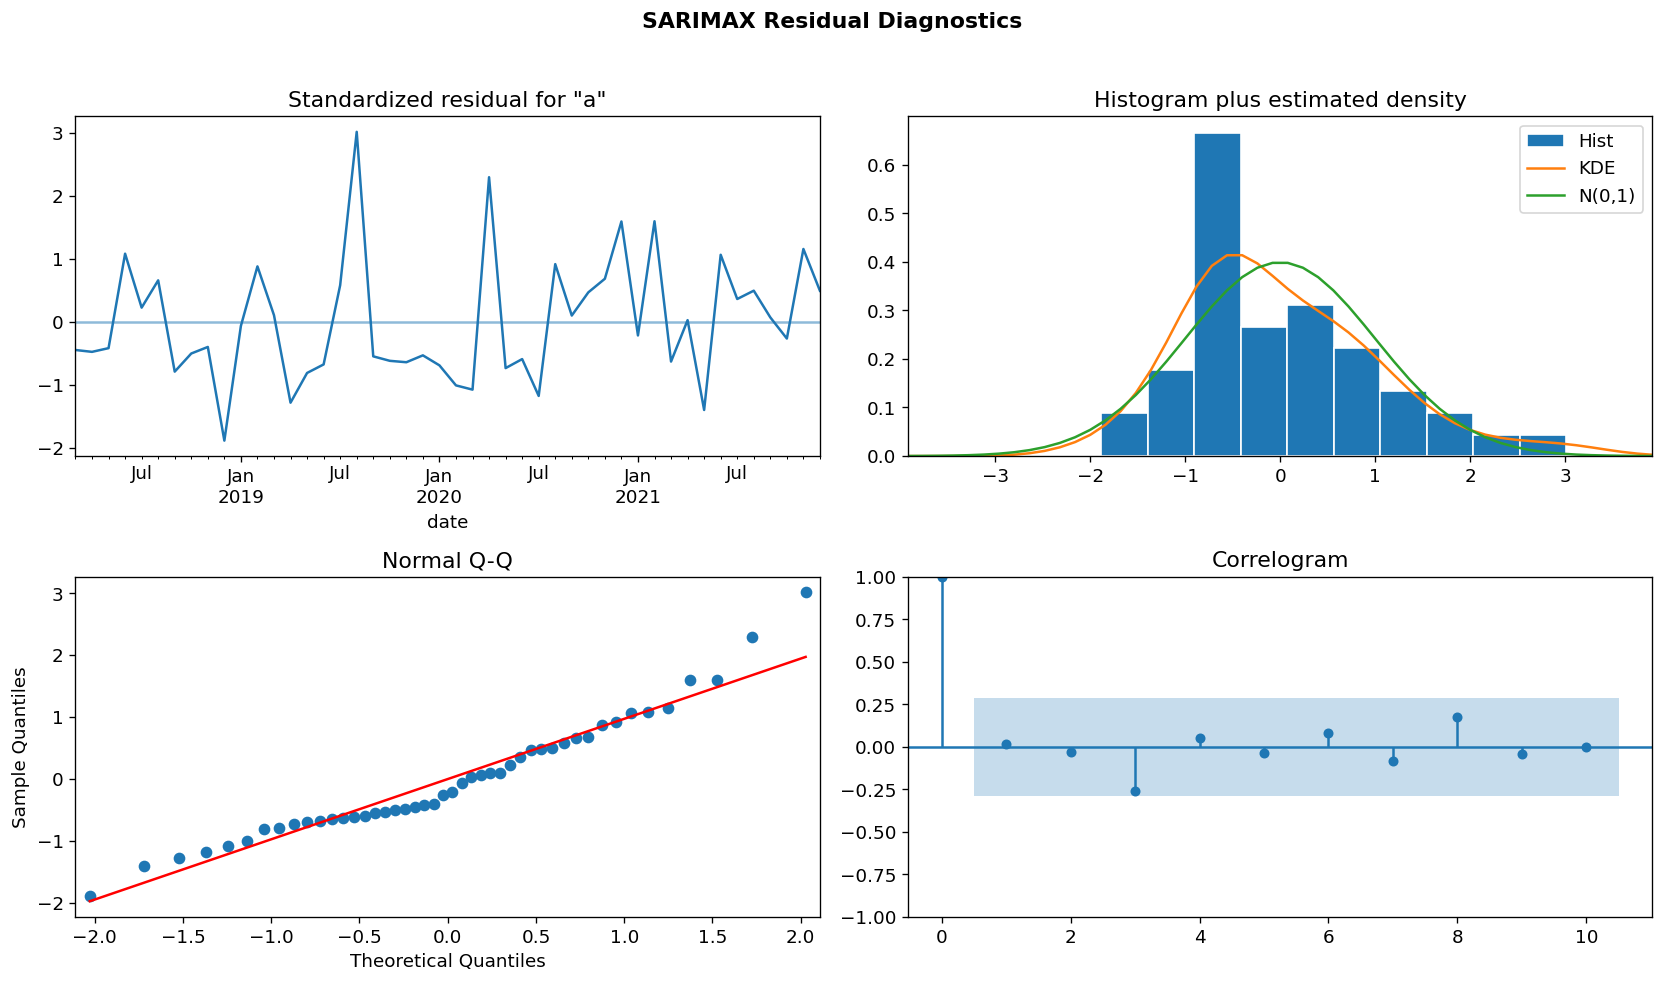

Figure saved: 06_residual_diagnostics.png


In [12]:
# Statsmodels built-in diagnostic plots
fig = sarima_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMAX Residual Diagnostics', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_residual_diagnostics.png', bbox_inches='tight')
plt.show()
print('Figure saved: 06_residual_diagnostics.png')

In [15]:
# Ljung-Box test for residual autocorrelation
residuals = sarima_fit.resid
lb_test = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)

print('Ljung-Box Test for Residual Autocorrelation:')
print('(H0: No autocorrelation in residuals — p > 0.05 means residuals are white noise)')
print()
print(lb_test.to_string())

all_pass = (lb_test['lb_pvalue'] > 0.05).all()
print()
print(f'Residuals are white noise: {"YES" if all_pass else "NO — model may be mis-specified"}')

Ljung-Box Test for Residual Autocorrelation:
(H0: No autocorrelation in residuals — p > 0.05 means residuals are white noise)

      lb_stat  lb_pvalue
6    4.690376   0.584092
12  10.317404   0.588137
24  20.510952   0.667380

Residuals are white noise: YES


## 12. Monthly Prediction Table

In [16]:
results_df = pd.DataFrame({
    'Date': test_y.index,
    'Actual_SO2': test_y.values,
    'Predicted_SO2': forecast_mean.values,
    'CI_Lower': conf_int.iloc[:, 0].values,
    'CI_Upper': conf_int.iloc[:, 1].values,
})
results_df['Absolute_Error'] = abs(results_df['Actual_SO2'] - results_df['Predicted_SO2'])
results_df['Pct_Error'] = (results_df['Absolute_Error'] / results_df['Actual_SO2'] * 100).round(2)

print('Monthly Forecast vs Actual (Test Set — 2022):')
print(results_df.to_string(index=False, float_format='%.6f'))

results_df.to_csv('sarima_forecast_results.csv', index=False)
print('\nResults saved: sarima_forecast_results.csv')

Monthly Forecast vs Actual (Test Set — 2022):
      Date  Actual_SO2  Predicted_SO2  CI_Lower  CI_Upper  Absolute_Error  Pct_Error
2022-01-01    0.001200       0.001144  0.001004  0.001285        0.000056   4.640000
2022-02-01    0.001100       0.001124  0.000973  0.001275        0.000024   2.200000
2022-03-01    0.001200       0.001149  0.000998  0.001300        0.000051   4.230000
2022-04-01    0.001200       0.001169  0.001018  0.001320        0.000031   2.580000
2022-05-01    0.001100       0.001143  0.000993  0.001294        0.000043   3.950000
2022-06-01    0.001200       0.001197  0.001046  0.001348        0.000003   0.230000
2022-07-01    0.001200       0.001183  0.001032  0.001334        0.000017   1.410000
2022-08-01    0.001200       0.001192  0.001041  0.001343        0.000008   0.640000
2022-09-01    0.001200       0.001188  0.001037  0.001339        0.000012   1.010000
2022-10-01    0.001200       0.001165  0.001014  0.001316        0.000035   2.950000
2022-11-01    0.001

## 13. Model Comparison Baseline Summary

In [17]:
import json

summary = {
    'model': 'SARIMAX',
    'target': 'air_so2',
    'features': ['ipi_abs_index_sa', 'electricity_local'],
    'order': str(order),
    'seasonal_order': str(seasonal_order),
    'train_period': f'{train_y.index[0].date()} to {train_y.index[-1].date()}',
    'test_period': f'{test_y.index[0].date()} to {test_y.index[-1].date()}',
    'metrics': {
        'train': train_metrics,
        'test': test_metrics
    },
    'aic': round(sarima_fit.aic, 4),
    'bic': round(sarima_fit.bic, 4),
}

print(json.dumps(summary, indent=2))

with open('sarima_model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('\nSummary saved: sarima_model_summary.json')

{
  "model": "SARIMAX",
  "target": "air_so2",
  "features": [
    "ipi_abs_index_sa",
    "electricity_local"
  ],
  "order": "(0, 0, 1)",
  "seasonal_order": "(0, 0, 0, 12)",
  "train_period": "2018-01-01 to 2021-12-01",
  "test_period": "2022-01-01 to 2022-12-01",
  "metrics": {
    "train": {
      "MAE": 5.5671777223173166e-05,
      "RMSE": 6.95427443933307e-05,
      "MAPE": 5.299334656150532,
      "R2": 0.3134572176198325
    },
    "test": {
      "MAE": 3.6667692088360355e-05,
      "RMSE": 4.954437352333081e-05,
      "MAPE": 3.026899466978116,
      "R2": -0.009911064245666124
    }
  },
  "aic": -741.5751,
  "bic": -734.2605
}

Summary saved: sarima_model_summary.json
